In [25]:
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from scipy.spatial.distance import squareform

from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression



import importlib
import bootstrap
import cifar10_patch_analysis
import distribution_estimation
import plotting
import model_wrapper
import performance_comparison
# Reload modules to pick up latest changes
importlib.reload(bootstrap)
importlib.reload(distribution_estimation)
importlib.reload(plotting)
importlib.reload(model_wrapper)
importlib.reload(performance_comparison)
importlib.reload(cifar10_patch_analysis)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *
from cifar10_patch_analysis import (
    load_bootstrap_runs, fit_patch_distributions,
    plot_image_explanation, plot_patch_importance_summary,
)
print("Modules reloaded successfully!")

Modules reloaded successfully!


In [26]:
run0 = np.load("shap_results/bootstrap_runs 2/run_000/shap_results/patch_shap.npy", allow_pickle=True)

In [3]:
run0.shape

(100, 8, 8)

In [4]:
run_root = "shap_results/bootstrap_runs 2"
run_dirs = sorted(
    d for d in os.listdir(run_root)
    if d.startswith("run_") and os.path.isdir(os.path.join(run_root, d, "shap_results"))
)

cifar_boot_results = []

for run_name in run_dirs:
    run_idx = int(run_name.split("_")[-1])
    patch_shap = np.load(
        os.path.join(run_root, run_name, "shap_results", "patch_shap.npy"),
        allow_pickle=True,
    )

    if patch_shap.ndim != 3:
        raise ValueError(f"Expected patch_shap to have shape (n_images, n_rows, n_cols), got {patch_shap.shape}")

    abs_shap = np.abs(patch_shap)
    sum_abs_shap = abs_shap.sum(axis=0)
    mean_abs_shap = abs_shap.mean(axis=0)
    n_images, n_rows, n_cols = patch_shap.shape

    rows = []
    for row_idx in range(n_rows):
        for col_idx in range(n_cols):
            rows.append({
                "feature": f"r{row_idx}c{col_idx}",
                "bootstrap_id": run_idx,
                "perm_round": 0,
                "sum_abs_shap": float(sum_abs_shap[row_idx, col_idx]),
                "mean_abs_shap": float(mean_abs_shap[row_idx, col_idx]),
                "n_samples": int(n_images),
            })

    cifar_boot_results.append(pd.DataFrame(rows))

print(f"Loaded {len(cifar_boot_results)} runs")
print(cifar_boot_results[0].head())

Loaded 50 runs
  feature  bootstrap_id  perm_round  sum_abs_shap  mean_abs_shap  n_samples
0    r0c0             0           0      0.026760       0.000268        100
1    r0c1             0           0      0.030242       0.000302        100
2    r0c2             0           0      0.023102       0.000231        100
3    r0c3             0           0      0.024466       0.000245        100
4    r0c4             0           0      0.020315       0.000203        100


In [21]:
boot_results, images, labels, predicted = load_bootstrap_runs()
dist_df = fit_patch_distributions(boot_results)

Auto bandwidth (Scott's rule, n=50): 2.656e-04
Fitted distributions: 6400 (sample_id, patch) pairs


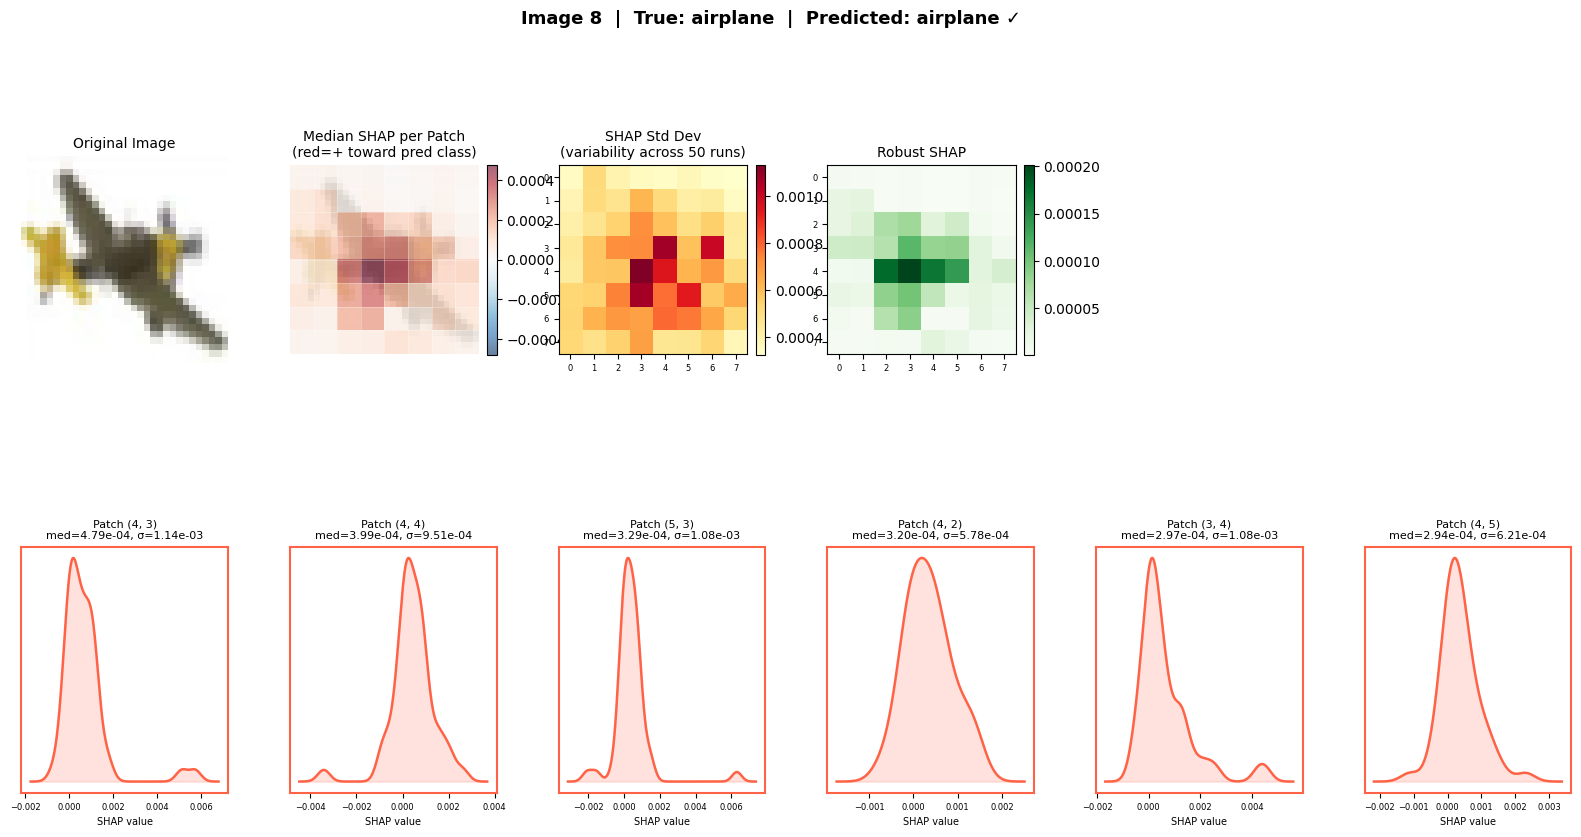

In [27]:
fig = plot_image_explanation(8, dist_df, images, labels, predicted)
plt.show()

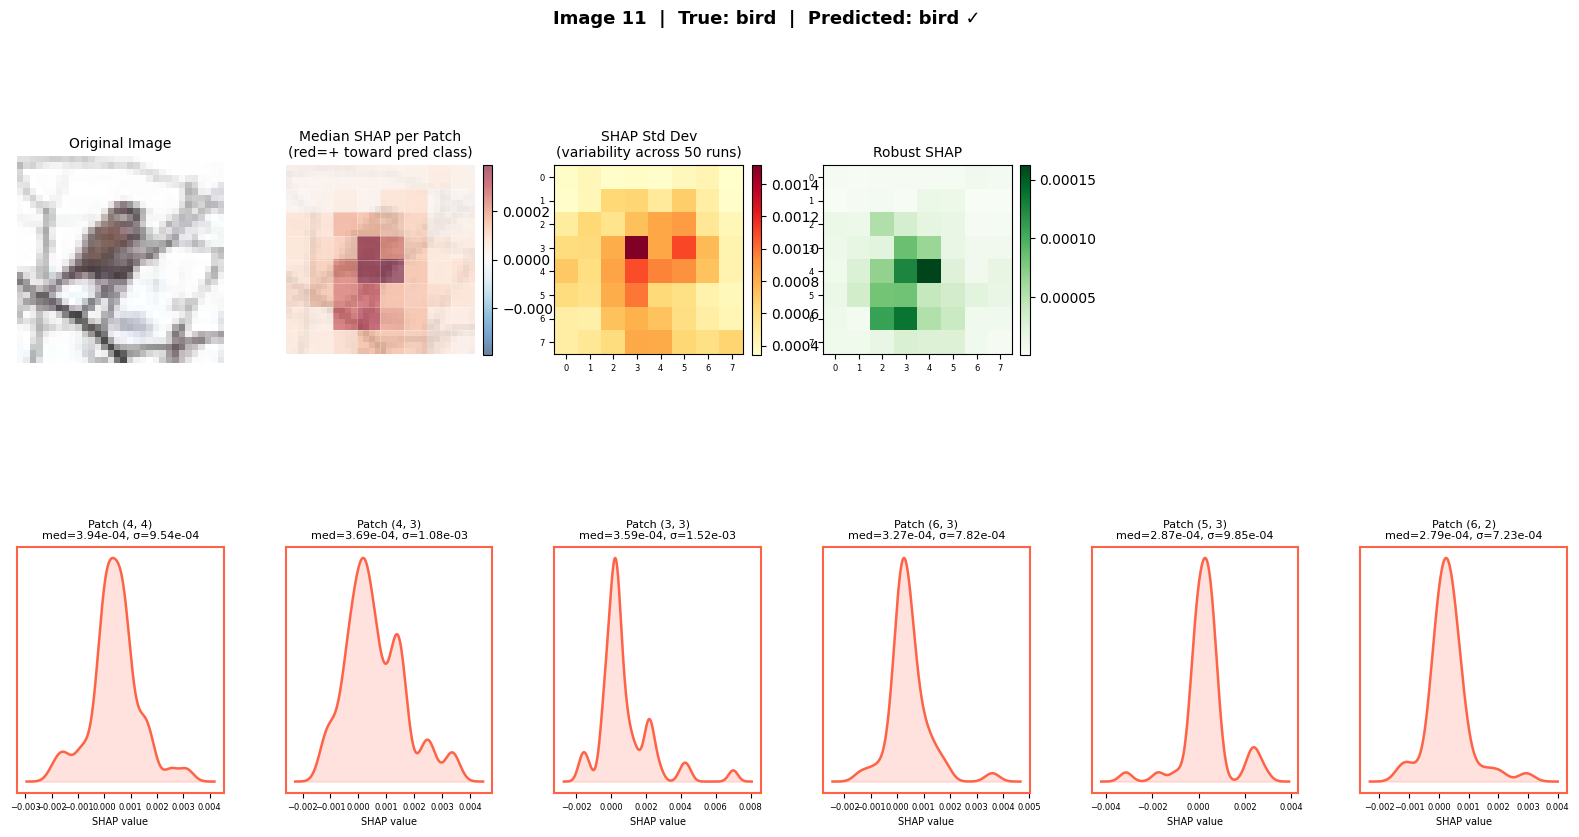

In [28]:
fig = plot_image_explanation(11, dist_df, images, labels, predicted)
plt.show()

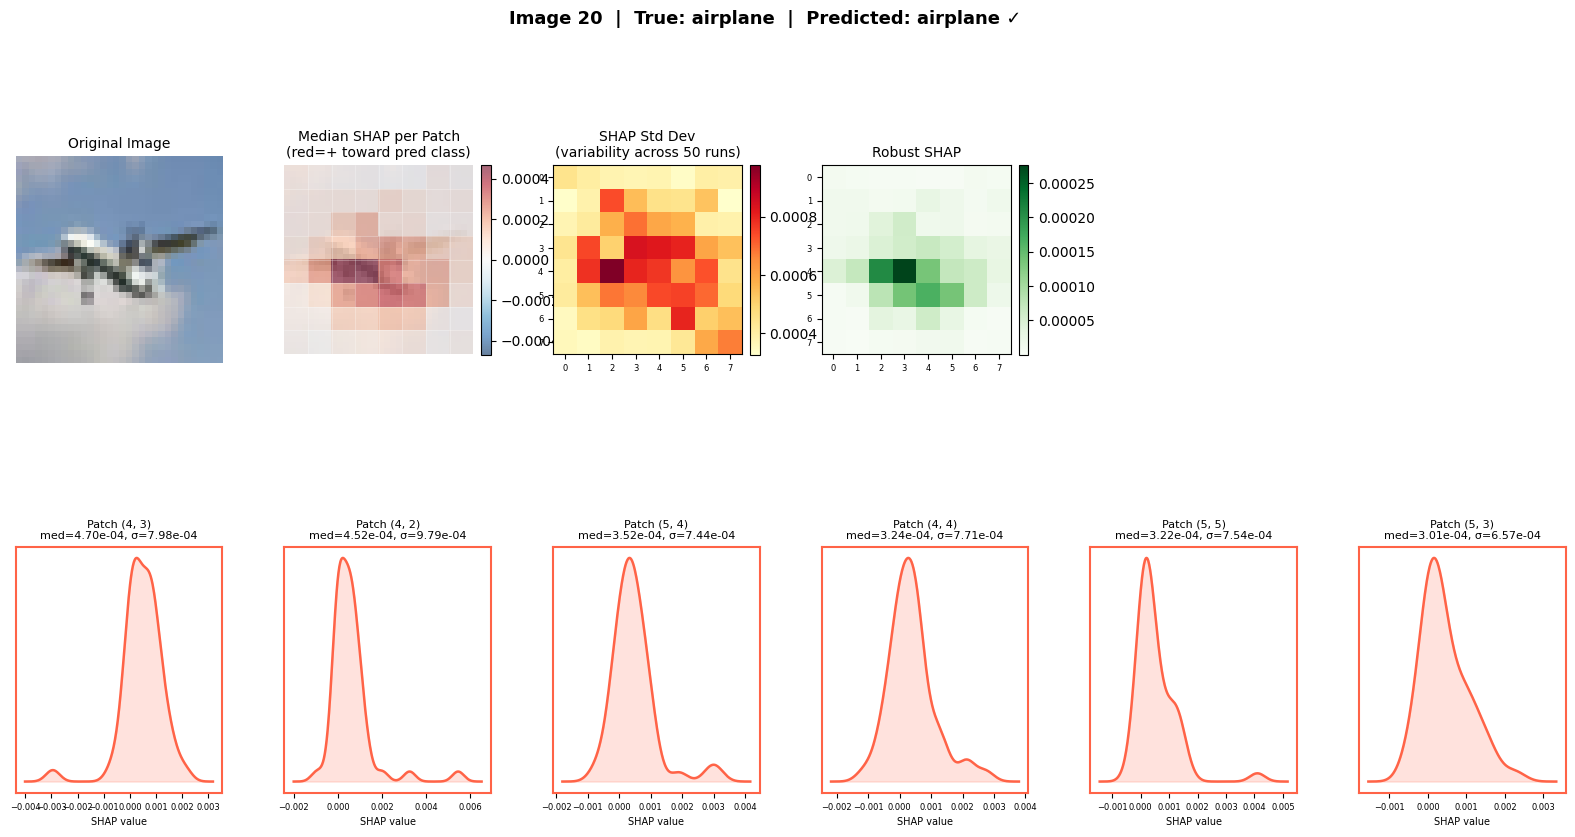

In [37]:
fig = plot_image_explanation(20, dist_df, images, labels, predicted)
plt.show()

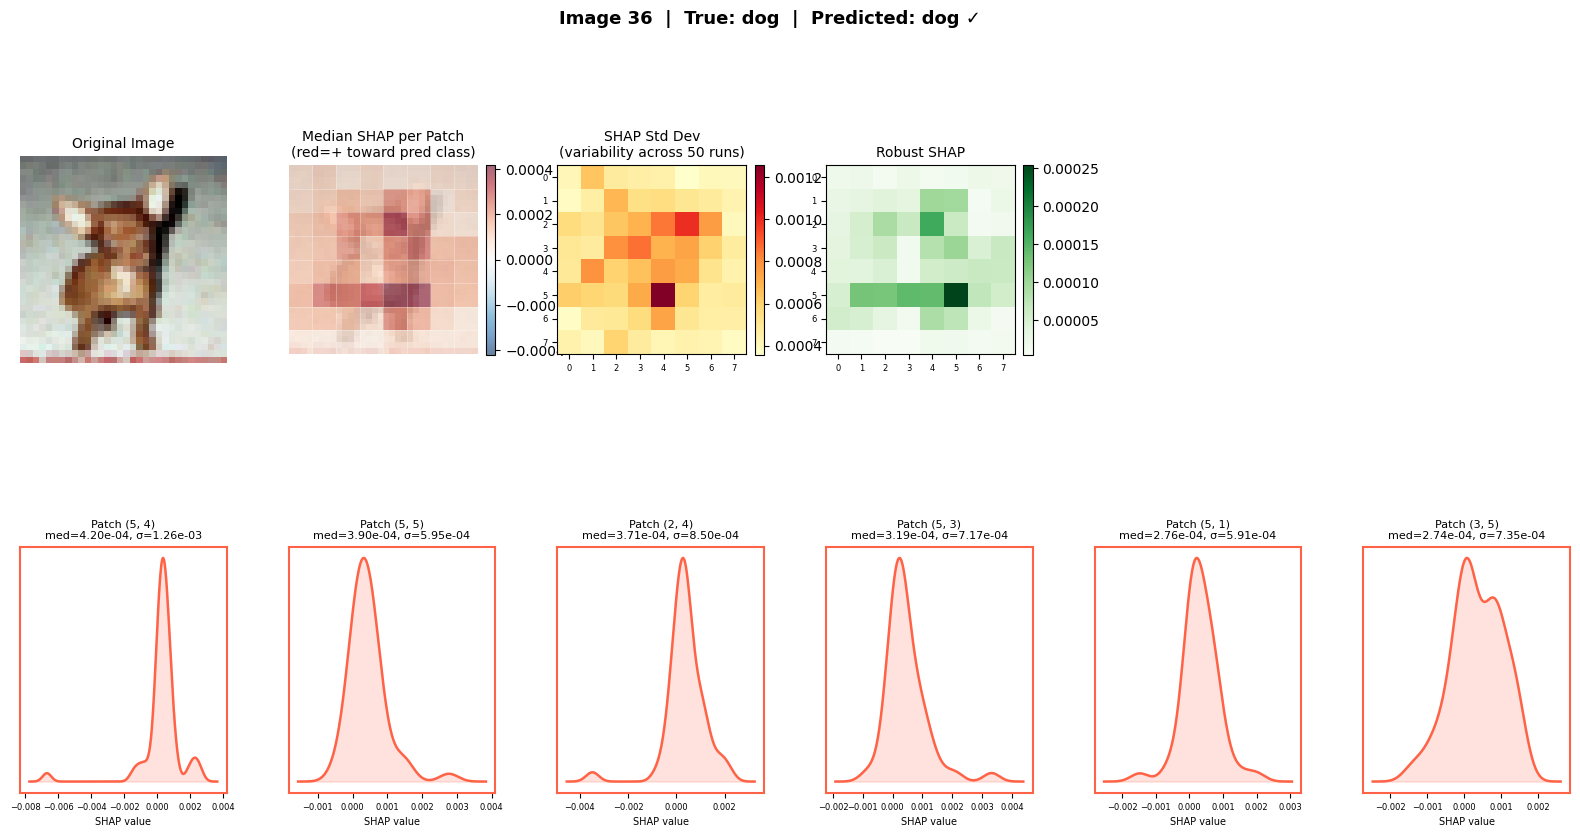

In [55]:
fig = plot_image_explanation(36, dist_df, images, labels, predicted)
plt.show()

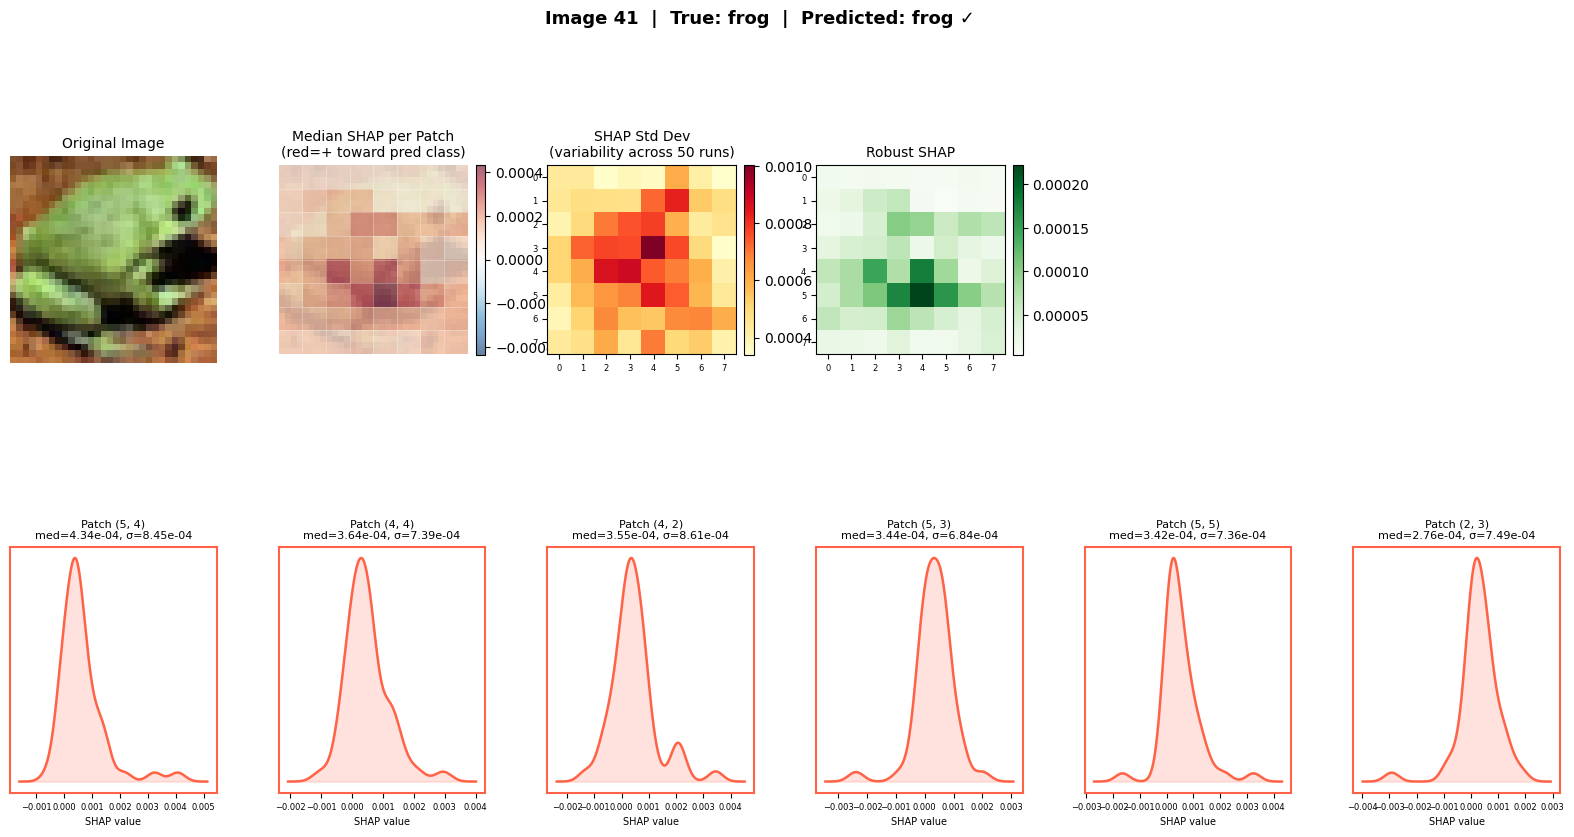

In [60]:
fig = plot_image_explanation(41, dist_df, images, labels, predicted)
plt.show()

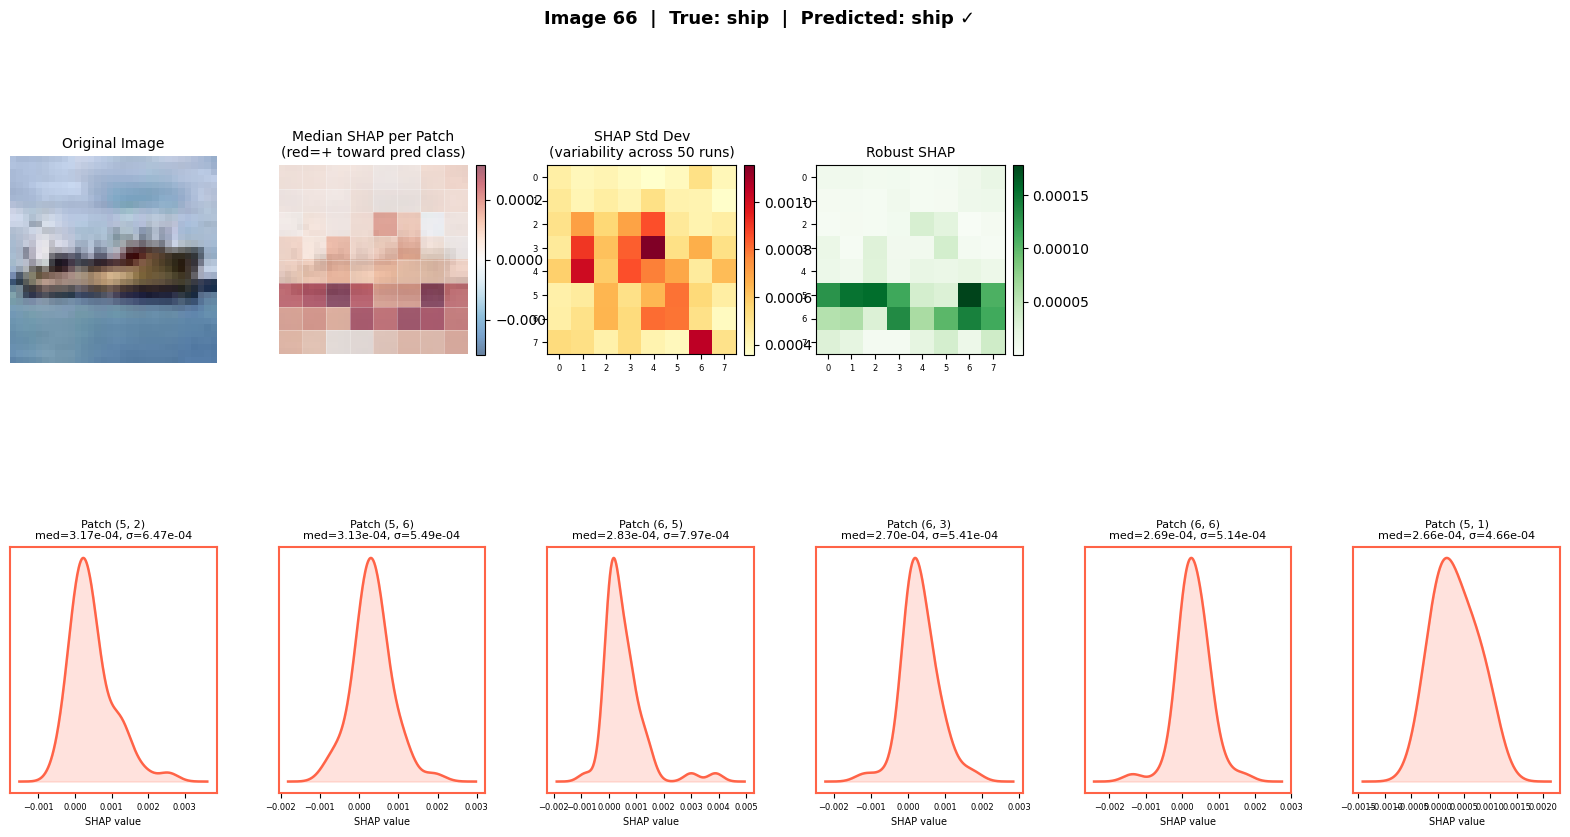

In [86]:
fig = plot_image_explanation(66, dist_df, images, labels, predicted)
plt.show()

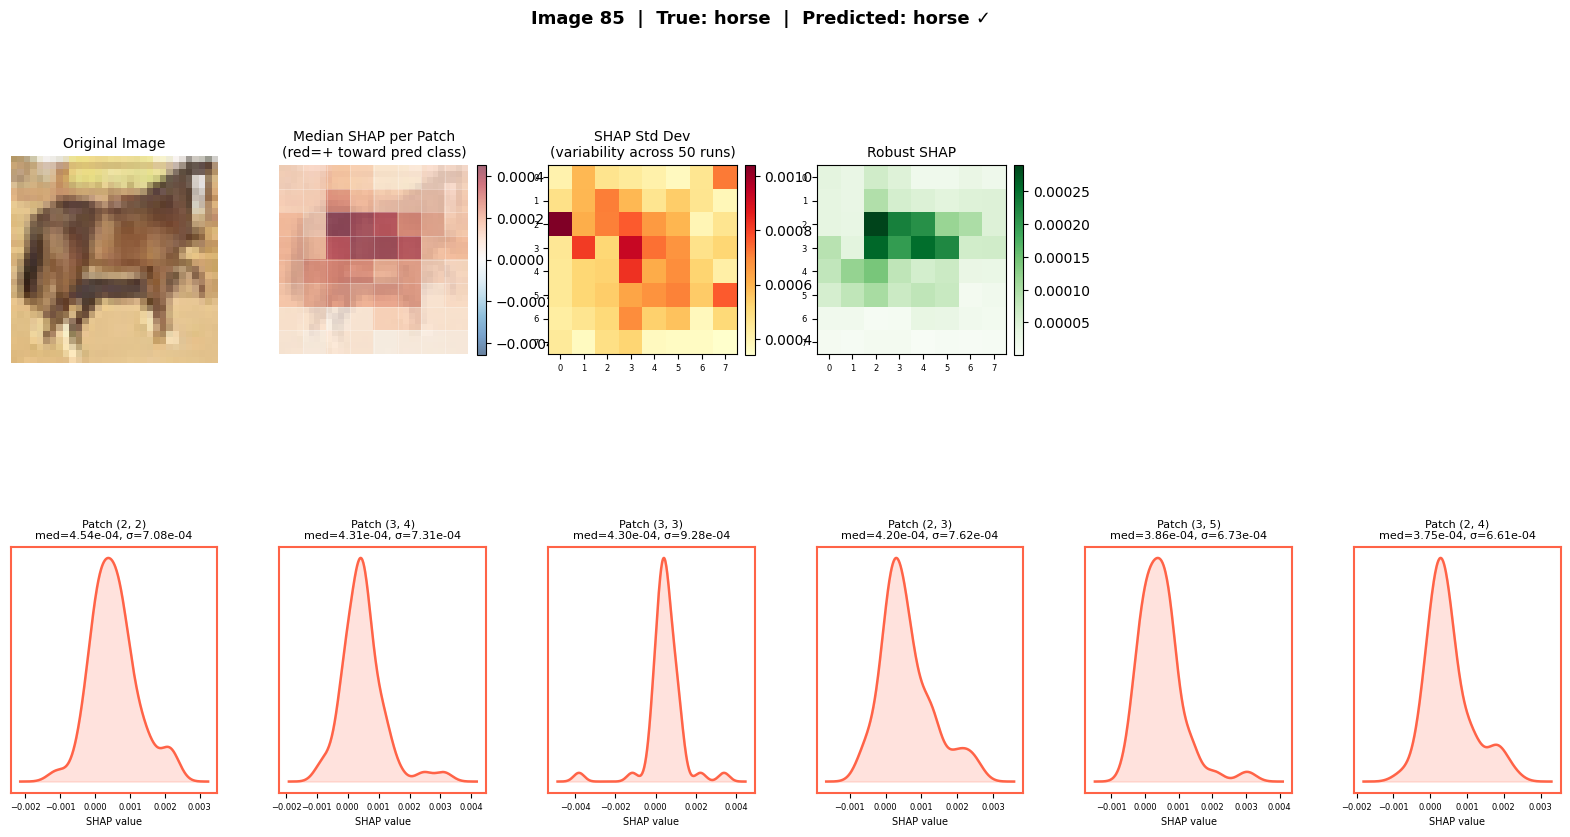

In [106]:
fig = plot_image_explanation(85, dist_df, images, labels, predicted)
plt.show()

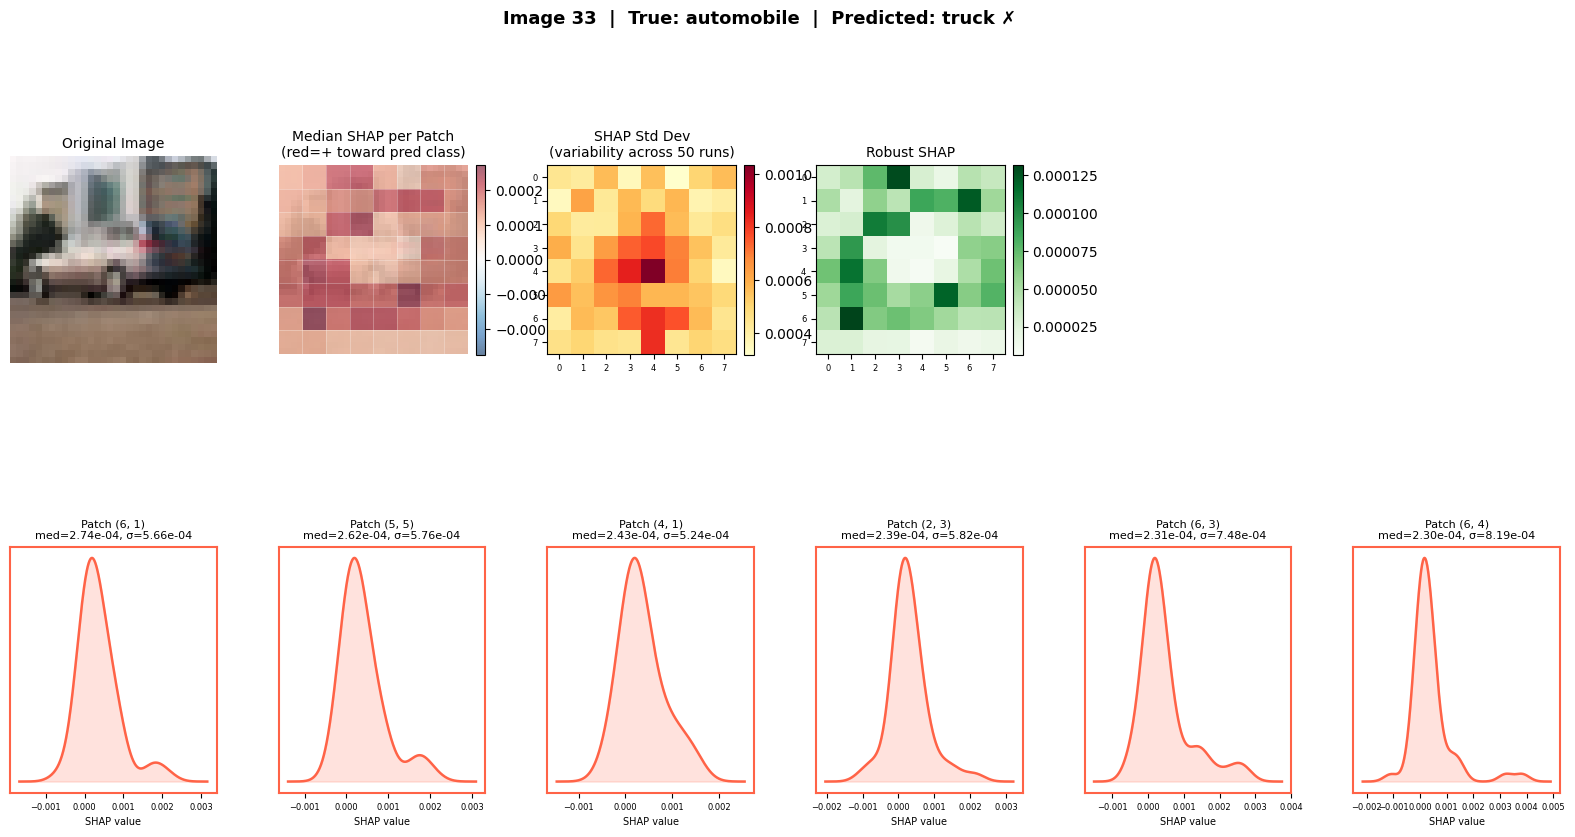

In [156]:
fig = plot_image_explanation(33, dist_df, images, labels, predicted)
plt.show()

In [160]:
# for i in range(100):
#     fig = plot_image_explanation(i, dist_df, images, labels, predicted)
#     plt.show()

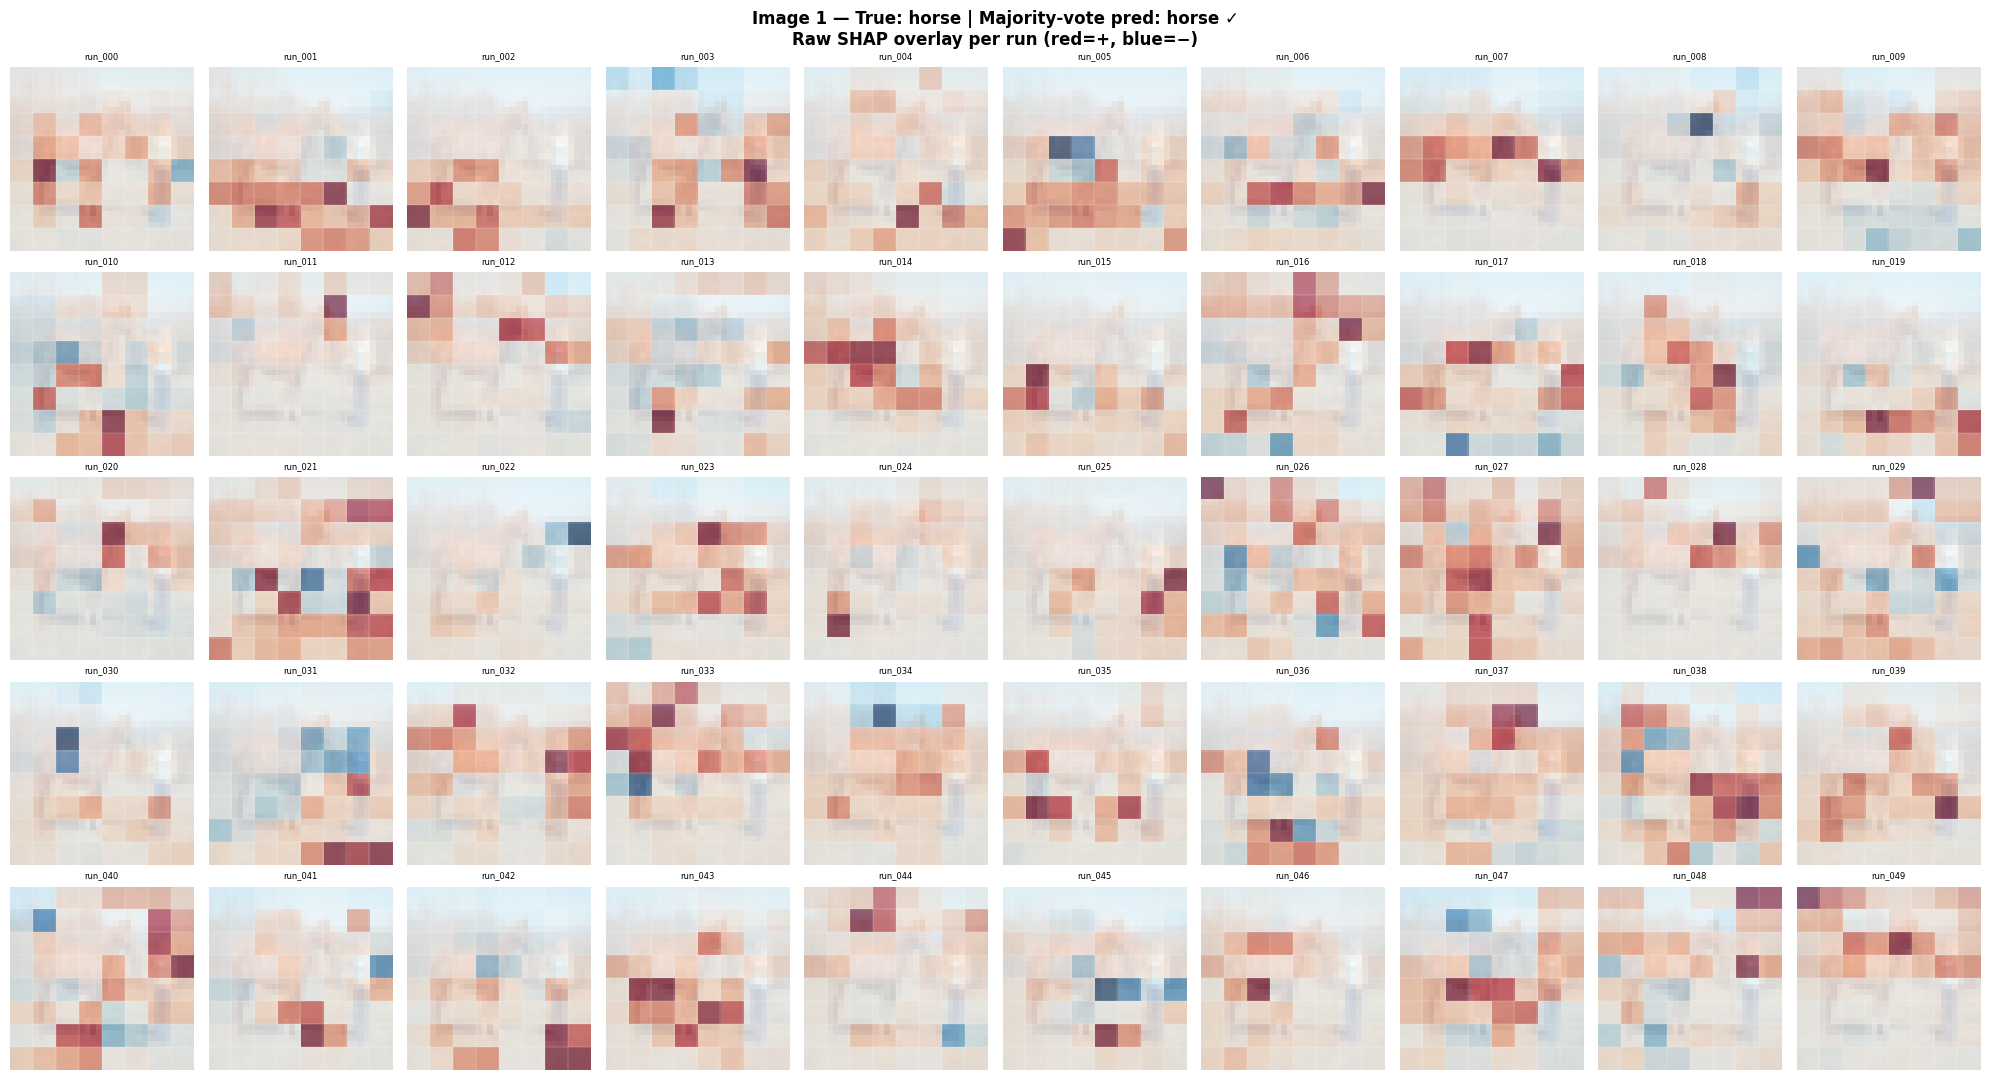

In [161]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

image_idx = 1  # ← change this to your selected image

run_root = "shap_results/bootstrap_runs 2"
run_dirs = sorted(
    d for d in os.listdir(run_root)
    if d.startswith("run_") and os.path.isdir(os.path.join(run_root, d, "shap_results"))
)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

img = images[image_idx]
true_cls = CIFAR10_CLASSES[labels[image_idx]]
pred_cls = CIFAR10_CLASSES[predicted[image_idx]]
match = "✓" if labels[image_idx] == predicted[image_idx] else "✗"

n_cols = 10
n_rows = (len(run_dirs) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.2))
axes = axes.ravel()

fig.suptitle(
    f"Image {image_idx} — True: {true_cls} | Majority-vote pred: {pred_cls} {match}\n"
    f"Raw SHAP overlay per run (red=+, blue=−)",
    fontsize=12, fontweight="bold",
)

for i, run_name in enumerate(run_dirs):
    shap_all = np.load(
        os.path.join(run_root, run_name, "shap_results", "patch_shap.npy")
    )  # (100, 8, 8)
    shap_map = shap_all[image_idx]  # (8, 8)

    # upsample 8×8 → 32×32 to match image size
    shap_up = shap_map.repeat(4, axis=0).repeat(4, axis=1)

    vabs = max(np.abs(shap_map).max(), 1e-12)
    norm = TwoSlopeNorm(vcenter=0, vmin=-vabs, vmax=vabs)

    ax = axes[i]
    ax.imshow(img, alpha=0.45)
    ax.imshow(shap_up, cmap="RdBu_r", norm=norm, alpha=0.6)
    for k in range(1, 8):
        ax.axhline(k * 4 - 0.5, color="white", lw=0.3, alpha=0.5)
        ax.axvline(k * 4 - 0.5, color="white", lw=0.3, alpha=0.5)
    ax.set_title(run_name, fontsize=6)
    ax.axis("off")

for j in range(len(run_dirs), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()